In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow.keras as tfk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [4]:
# Generate synthetic dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
y = y.reshape(-1, 1)  # Reshape for consistency



In [31]:
X

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]], shape=(1000, 2))

In [21]:
# train test split 
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state=42)


In [22]:
#Building the sequential model
def bulid_linear_model():
    model = Sequential([
        Dense(10 , activation = 'linear' , input_dim = 2),
        Dense(1, activation = 'sigmoid' )
    ])

    # compiling the model 
    model.compile(optimizer = 'adam' , loss= 'binary_crossentropy' , metrics = ['accuracy'])

    return model 

In [23]:
#Building the sequential model
def bulid_relu_model():
    model = Sequential([
        Dense(10 , activation = 'relu' , input_dim = 2),
        Dense(1, activation = 'sigmoid' )
    ])

    # compiling the model 
    model.compile(optimizer = 'adam' , loss= 'binary_crossentropy' , metrics = ['accuracy'])

    return model 

In [24]:
#   model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
linear_model = bulid_linear_model()
relu_model = bulid_relu_model()

c:\Users\manas\OneDrive\Desktop\DL CampusX\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# function to train and evaluate the modes bulid
def train_eval(model , X_train = X_train , y_train = y_train , X_test = X_test , y_test = y_test , epochs = 50 , batch_size =32):
    model.fit(X_train , y_train , epochs = epochs , batch_size = 32 , verbose = 0)
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    accuracy = accuracy_score(y_test , y_pred)
    return accuracy , y_pred


In [27]:
# Train and evaluate linear model
print("Training linear model...")
linear_accuracy, linear_preds = train_eval(linear_model)
print(f"Accuracy with linear activation: {linear_accuracy:.2f}")

# Train and evaluate ReLU model
print("Training ReLU model...")
relu_accuracy, relu_preds = train_eval(relu_model)
print(f"Accuracy with ReLU activation: {relu_accuracy:.2f}")

Training linear model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy with linear activation: 0.86
Training ReLU model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
Accuracy with ReLU activation: 0.86


In [40]:
# Visualize decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1  , X[:, 0].max() + 1 
    y_min, y_max = X[:, 1].min() -1 , X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolor="k")
    plt.title(title)
    plt.show()



Visualizing decision boundaries...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


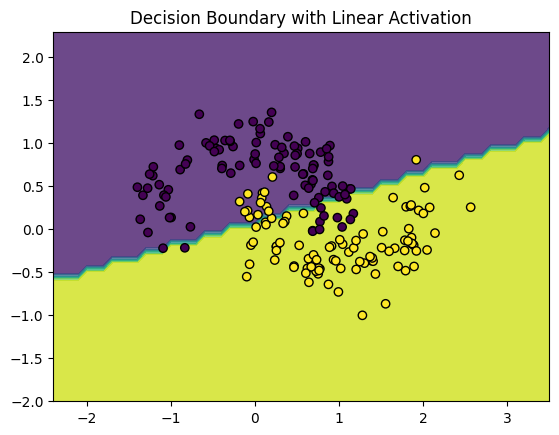

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step


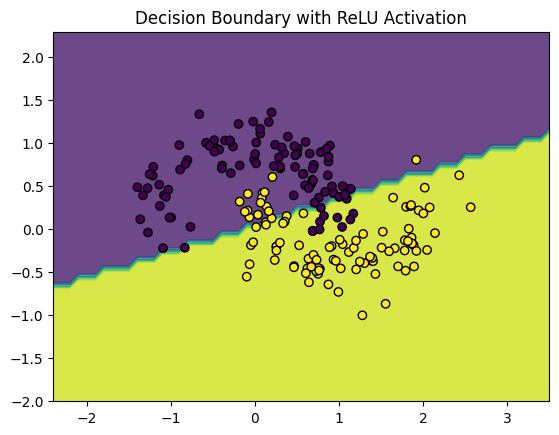

In [41]:
# Plot decision boundaries
print("\nVisualizing decision boundaries...")
plot_decision_boundary(linear_model, X_test, y_test, "Decision Boundary with Linear Activation")
plot_decision_boundary(relu_model, X_test, y_test, "Decision Boundary with ReLU Activation")

In [30]:
X

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]], shape=(1000, 2))